# Compare N-step vs. 1-step EDM generation results

## t-SNE plot from saved npz features
Uses `extrct_training_feats.npz`, `extrct_edm_feats.npz`, `extrct_dmd_feats.npz` in a class folder.
Background = training (very light); left = EDM (alpha by t-SNE x); right = DMD (same alpha as matching EDM).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Class folder containing the three npz files (e.g. 207_Golden_Retriever)
CLASS_DIR = "tsne_edm_1_vs_N/207_Golden_Retriever"

## Using All training, EDM, DMD data points, and visualize their joint t-SNE

In [ ]:
train = np.load(f"{CLASS_DIR}/extrct_training_feats.npz")
edm1 = np.load(f"{CLASS_DIR}/edm1_feats.npz")
edmN = np.load(f"{CLASS_DIR}/edmN_feats.npz")

bg_feats = train["features"]
edm1_feats = edm1["features"]
edmN_feats = edmN["features"]

n_bg, n_edm1, n_edmN = len(bg_feats), len(edm1_feats), len(edmN_feats)
print(f"Training: {n_bg}, EDM: {n_edm1}, DMD: {n_edmN}")

Training: 1300, EDM: 1000, DMD: 1000


In [36]:
all_feats = np.concatenate([bg_feats, edm_feats, dmd_feats], axis=0)
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, init="pca", random_state=0, verbose=1)
all_2d = tsne.fit_transform(all_feats)

bg_2d = all_2d[:n_bg]
edm_2d = all_2d[n_bg : n_bg + n_edm]
dmd_2d = all_2d[n_bg + n_edm :]

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 3300 samples in 0.004s...
[t-SNE] Computed neighbors for 3300 samples in 0.298s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3300
[t-SNE] Computed conditional probabilities for sample 2000 / 3300
[t-SNE] Computed conditional probabilities for sample 3000 / 3300
[t-SNE] Computed conditional probabilities for sample 3300 / 3300
[t-SNE] Mean sigma: 1.844302
[t-SNE] KL divergence after 250 iterations with early exaggeration: 81.405838
[t-SNE] KL divergence after 1000 iterations: 2.525640


In [37]:
min_pairs = min(n_edm, n_dmd)
edm_x = edm_2d[:min_pairs, 0].astype(np.float64)
x_min, x_max = edm_x.min(), edm_x.max()
x_norm = (edm_x - x_min) / (x_max - x_min + 1e-12)  # 0 = left, 1 = right

# EDM: left→right = blue→red; DMD: same color as corresponding EDM point (same noise seed)
cmap = plt.cm.get_cmap("coolwarm")  # blue (0) → red (1)
edm_colors = cmap(x_norm)  # (N, 4) RGBA
dmd_colors = edm_colors.copy()  # same color for matching index

/tmp/ipykernel_39719/2743464302.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("coolwarm")  # blue (0) → red (1)


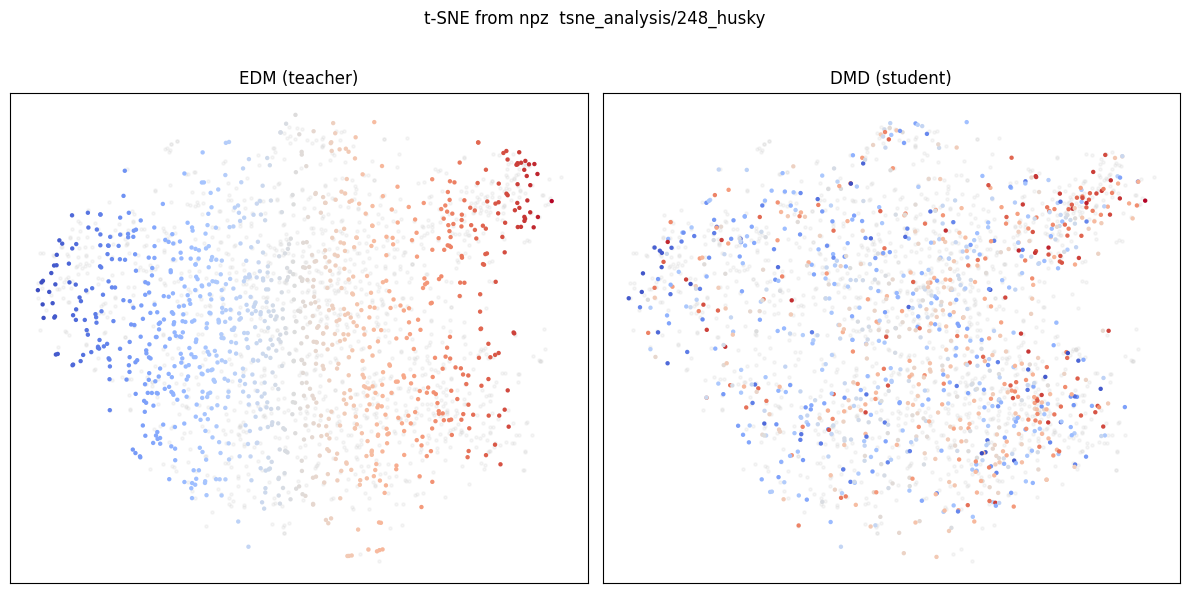

Saved tsne_analysis/248_husky/t_SNE_from_npz.png


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

for ax in axes:
    ax.scatter(bg_2d[:, 0], bg_2d[:, 1], s=5, c="lightgray", alpha=0.2, label="Train")
    ax.set_xticks([])
    ax.set_yticks([])

axes[0].scatter(edm_2d[:min_pairs, 0], edm_2d[:min_pairs, 1], s=10, color=edm_colors, edgecolors="none", label="EDM")
axes[0].set_title("EDM (teacher)")

axes[1].scatter(dmd_2d[:min_pairs, 0], dmd_2d[:min_pairs, 1], s=10, color=dmd_colors, edgecolors="none", label="DMD")
axes[1].set_title("DMD (student)")

fig.suptitle(f"t-SNE from npz  {CLASS_DIR}")
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f"{CLASS_DIR}/t_SNE_from_npz.png", dpi=200)
plt.show()
print(f"Saved {CLASS_DIR}/t_SNE_from_npz.png")

Plot $K$ pairs of images with largest / smallest t-SNE distance.

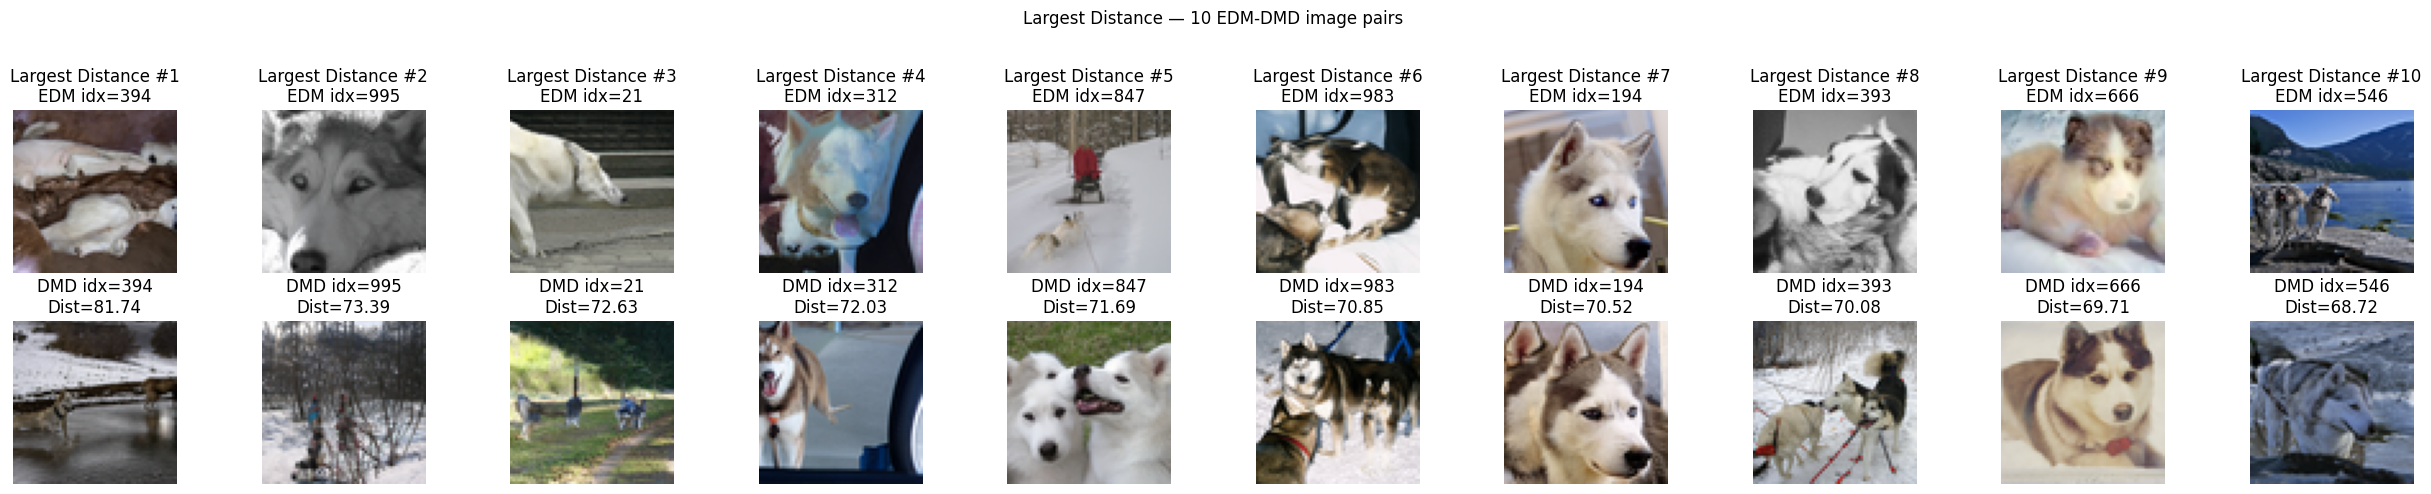

Saved tsne_analysis/248_husky/img_EDM_DMD_largest_10_pairs.png


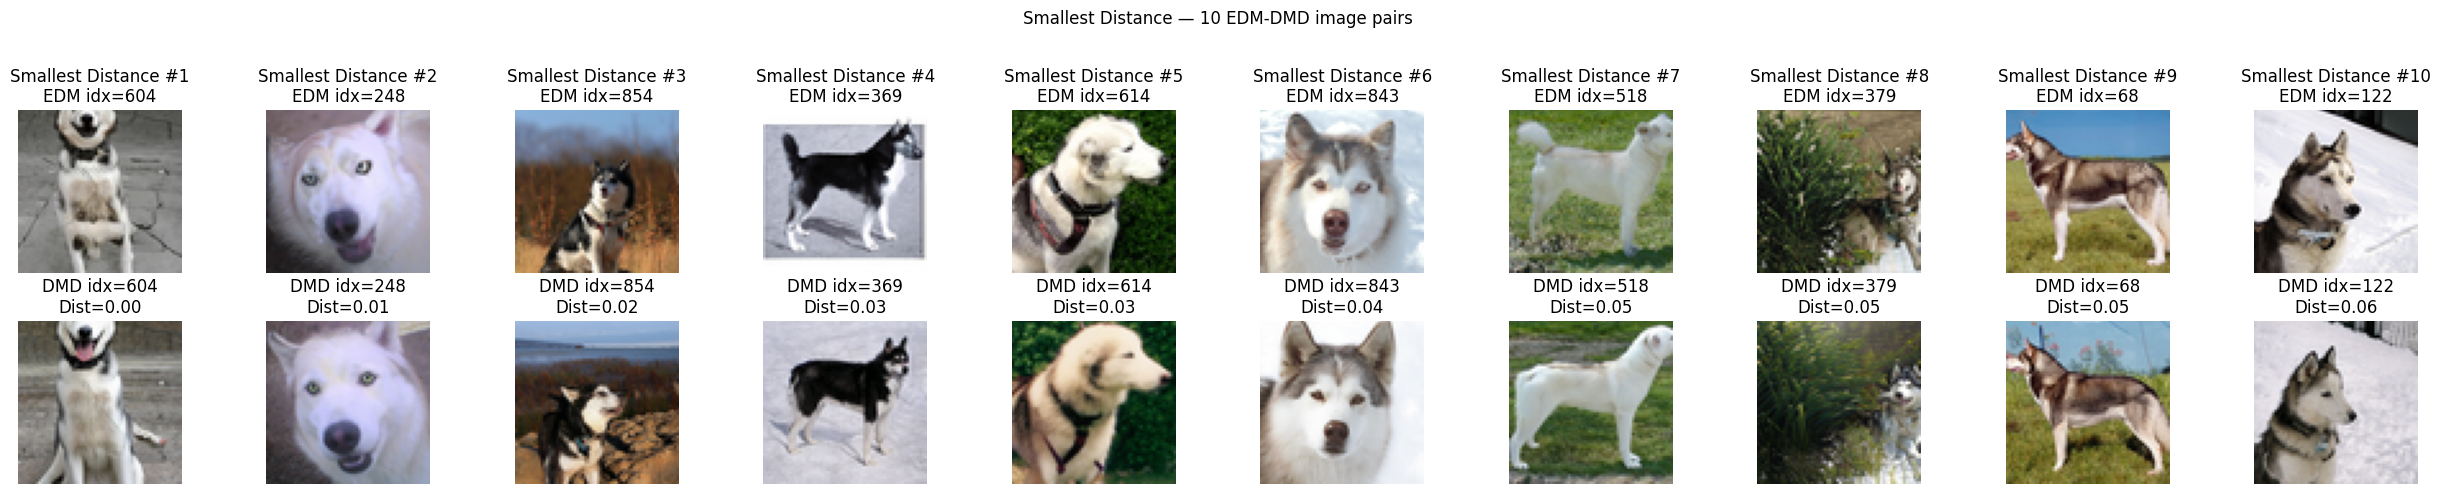

Saved tsne_analysis/248_husky/img_EDM_DMD_smallest_10_pairs.png


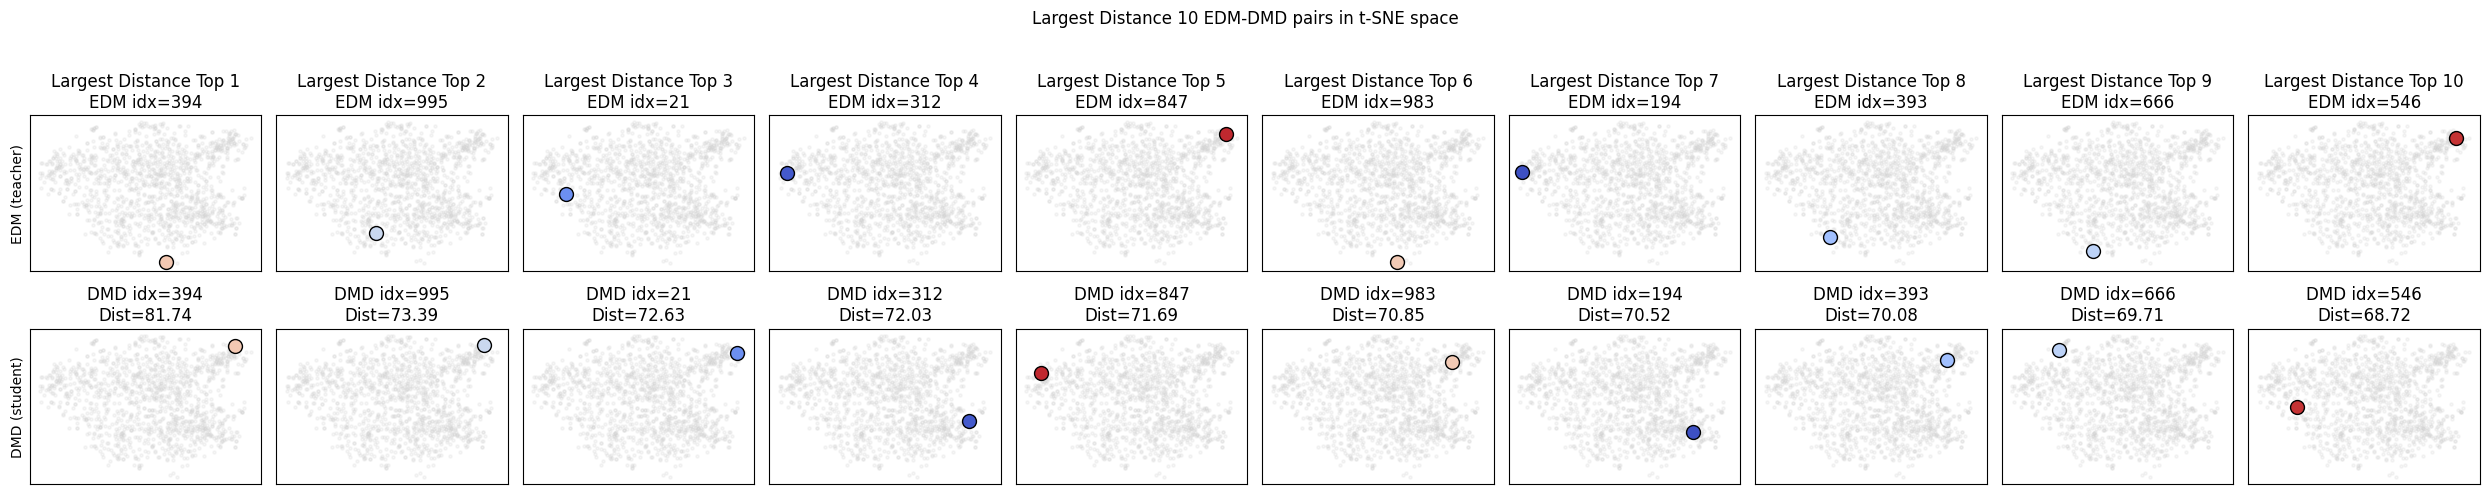

Saved tsne_analysis/248_husky/tSNE_EDM_DMD_largest_10_pairs.png


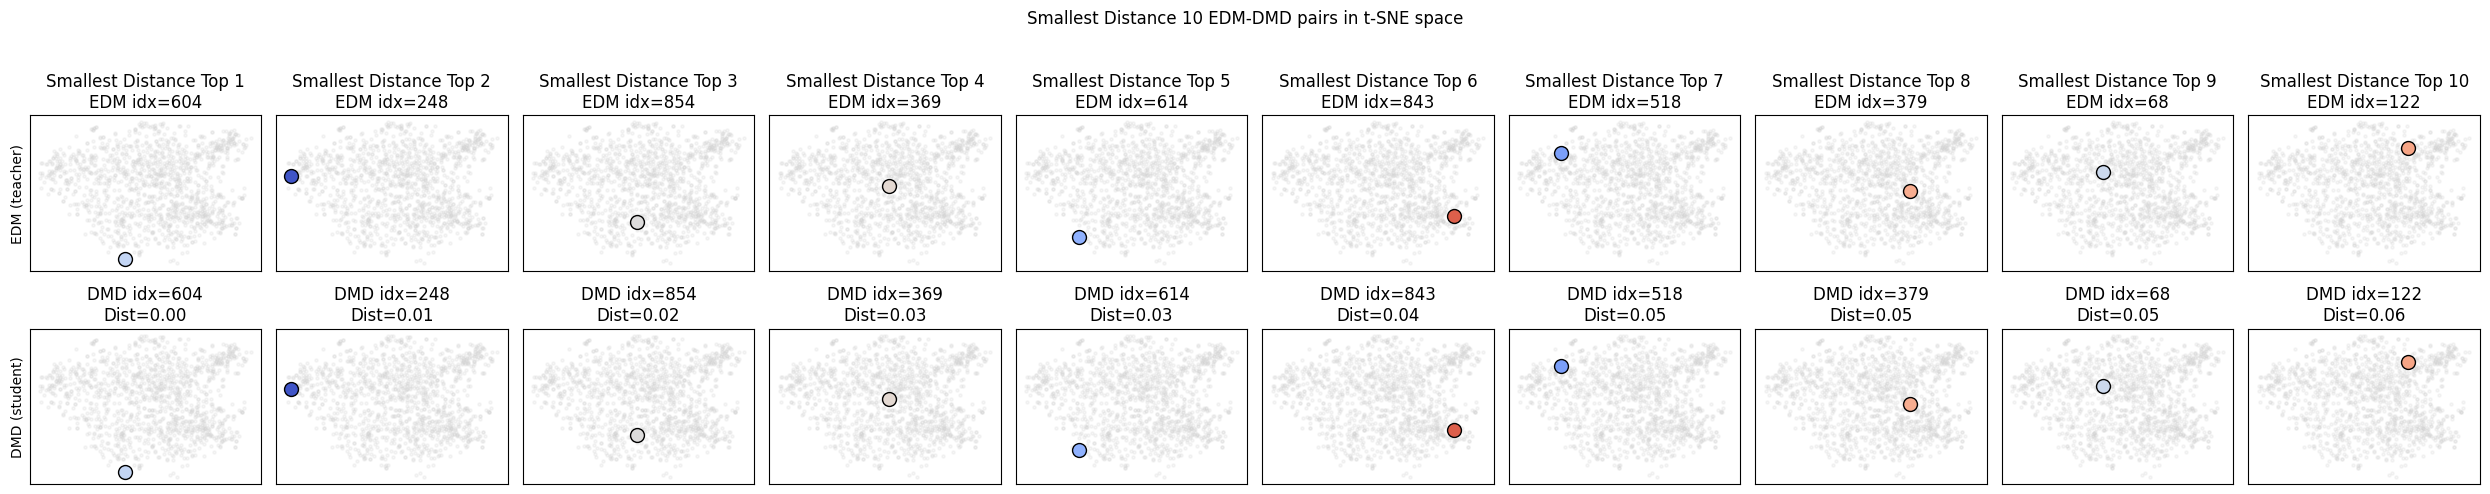

Saved tsne_analysis/248_husky/tSNE_EDM_DMD_smallest_10_pairs.png


In [39]:
# 找出t-SNE空间里EDM和DMD距离最大的K=10和最小的K=10对点，再 pairwise 画对应生成的照片
import os
from PIL import Image

K = 10
# 先算距离并选出最大/最小的 K 对
diffs = edm_2d[:min_pairs] - dmd_2d[:min_pairs]
dists = np.linalg.norm(diffs, axis=1)
max_idxs = np.argsort(dists)[-K:][::-1]  # 最大的K个，降序
min_idxs = np.argsort(dists)[:K]         # 最小的K个，升序

# 生成图所在目录（与 tsne_edm_dmd_imagenet.py 保存一致）
edm_img_dir = f"{CLASS_DIR}/edm_images"
dmd_img_dir = f"{CLASS_DIR}/dmd_images"

def plot_image_pairs(idx_list, title_prefix, edm_dir, dmd_dir, dists_arr):
    """按 index 读取 EDM/DMD 原图并并排画：上排 EDM，下排 DMD。文件名 edm_0000.png / dmd_0000.png"""
    fig, axes = plt.subplots(2, K, figsize=(2.5*K, 5))
    for i, idx in enumerate(idx_list):
        edm_img_path = os.path.join(edm_dir, f"edm_{idx:04d}.png")
        dmd_img_path = os.path.join(dmd_dir, f"dmd_{idx:04d}.png")
        try:
            edm_img = np.array(Image.open(edm_img_path))
        except Exception as e:
            edm_img = np.zeros((64, 64, 3), dtype=np.uint8)
            print(f"Failed to load {edm_img_path}: {e}")
        try:
            dmd_img = np.array(Image.open(dmd_img_path))
        except Exception as e:
            dmd_img = np.zeros((64, 64, 3), dtype=np.uint8)
            print(f"Failed to load {dmd_img_path}: {e}")
        axes[0, i].imshow(edm_img)
        axes[0, i].axis("off")
        axes[0, i].set_title(f"{title_prefix} #{i+1}\nEDM idx={idx}")
        axes[1, i].imshow(dmd_img)
        axes[1, i].axis("off")
        axes[1, i].set_title(f"DMD idx={idx}\nDist={dists_arr[idx]:.2f}")
    axes[0, 0].set_ylabel("EDM")
    axes[1, 0].set_ylabel("DMD")
    fig.suptitle(f"{title_prefix} — {K} EDM-DMD image pairs")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

fig_max_img = plot_image_pairs(max_idxs, "Largest Distance", edm_img_dir, dmd_img_dir, dists)
plt.savefig(f"{CLASS_DIR}/img_EDM_DMD_largest_{K}_pairs.png", dpi=150)
plt.show()
print(f"Saved {CLASS_DIR}/img_EDM_DMD_largest_{K}_pairs.png")

fig_min_img = plot_image_pairs(min_idxs, "Smallest Distance", edm_img_dir, dmd_img_dir, dists)
plt.savefig(f"{CLASS_DIR}/img_EDM_DMD_smallest_{K}_pairs.png", dpi=150)
plt.show()
print(f"Saved {CLASS_DIR}/img_EDM_DMD_smallest_{K}_pairs.png")

def plot_pairs(idx_list, title_prefix):
    fig, axes = plt.subplots(2, K, figsize=(2.5*K, 5))
    for i, idx in enumerate(idx_list):
        # EDM
        axes[0, i].scatter(bg_2d[:, 0], bg_2d[:, 1], s=5, c='lightgray', alpha=0.2)
        axes[0, i].scatter(edm_2d[idx, 0], edm_2d[idx, 1], s=100, color=edm_colors[idx][None, :], edgecolors="black", label="EDM")
        axes[0, i].set_xticks([])
        axes[0, i].set_yticks([])
        axes[0, i].set_title(f"{title_prefix} Top {i+1}\nEDM idx={idx}")
        # DMD
        axes[1, i].scatter(bg_2d[:, 0], bg_2d[:, 1], s=5, c='lightgray', alpha=0.2)
        axes[1, i].scatter(dmd_2d[idx, 0], dmd_2d[idx, 1], s=100, color=dmd_colors[idx][None, :], edgecolors="black", label="DMD")
        axes[1, i].set_xticks([])
        axes[1, i].set_yticks([])
        axes[1, i].set_title(f"DMD idx={idx}\nDist={dists[idx]:.2f}")
    axes[0, 0].set_ylabel("EDM (teacher)")
    axes[1, 0].set_ylabel("DMD (student)")
    fig.suptitle(f"{title_prefix} {K} EDM-DMD pairs in t-SNE space")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

fig_max = plot_pairs(max_idxs, "Largest Distance")
plt.savefig(f"{CLASS_DIR}/tSNE_EDM_DMD_largest_{K}_pairs.png", dpi=150)
plt.show()
print(f"Saved {CLASS_DIR}/tSNE_EDM_DMD_largest_{K}_pairs.png")

fig_min = plot_pairs(min_idxs, "Smallest Distance")
plt.savefig(f"{CLASS_DIR}/tSNE_EDM_DMD_smallest_{K}_pairs.png", dpi=150)
plt.show()
print(f"Saved {CLASS_DIR}/tSNE_EDM_DMD_smallest_{K}_pairs.png")

Plot the distribution of distance between DMD and EDM images in t-SNE space.

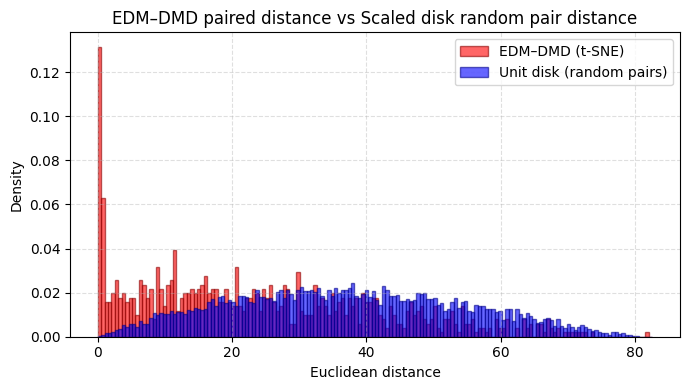

EDM–DMD distance distribution: mean=24.046, std=18.131
Random pairs from scaled disk: mean=37.084, std=17.192


In [40]:
# Function to simulate distances between two random points in a disk
def random_point_in_disk(n, rad=1):
    r = np.sqrt(np.random.rand(n)) * rad
    theta = 2 * np.pi * np.random.rand(n)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.stack([x, y], axis=1)
n_pairs = 10000
# Scale disk so distance range is comparable to EDM–DMD (t-SNE) distances
rad = max(dists.max() / 2, 1e-6)
np.random.seed(42)
pts1 = random_point_in_disk(n_pairs, rad)
pts2 = random_point_in_disk(n_pairs, rad)
disk_dists = np.linalg.norm(pts1 - pts2, axis=1)


# Overlay both distributions (red = EDM-DMD, blue = unit disk)
plt.figure(figsize=(7, 4))
x_max = max(dists.max(), disk_dists.max())
bins = np.linspace(0, x_max * 1.01, int(dists.max() * 2))
plt.hist(dists, bins=bins, color="red", alpha=0.6, density=True, label="EDM–DMD (t-SNE)", edgecolor="darkred")
plt.hist(disk_dists, bins=bins, color="blue", alpha=0.6, density=True, label="Unit disk (random pairs)", edgecolor="darkblue")
plt.xlabel("Euclidean distance")
plt.ylabel("Density")
plt.title("EDM–DMD paired distance vs Scaled disk random pair distance")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
print(f"EDM–DMD distance distribution: mean={dists.mean():.3f}, std={dists.std():.3f}")
print(f"Random pairs from scaled disk: mean={disk_dists.mean():.3f}, std={disk_dists.std():.3f}")

----

## DEPRECATE: Using only training as t-SNE, DMD and EDM plotted via nearest neighbors

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1300 samples in 0.001s...
[t-SNE] Computed neighbors for 1300 samples in 0.174s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1300
[t-SNE] Computed conditional probabilities for sample 1300 / 1300
[t-SNE] Mean sigma: 2.251819
[t-SNE] KL divergence after 250 iterations with early exaggeration: 80.151276
[t-SNE] KL divergence after 1000 iterations: 1.994408


/tmp/ipykernel_2660437/1683261540.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("coolwarm")  # blue (0) → red (1)


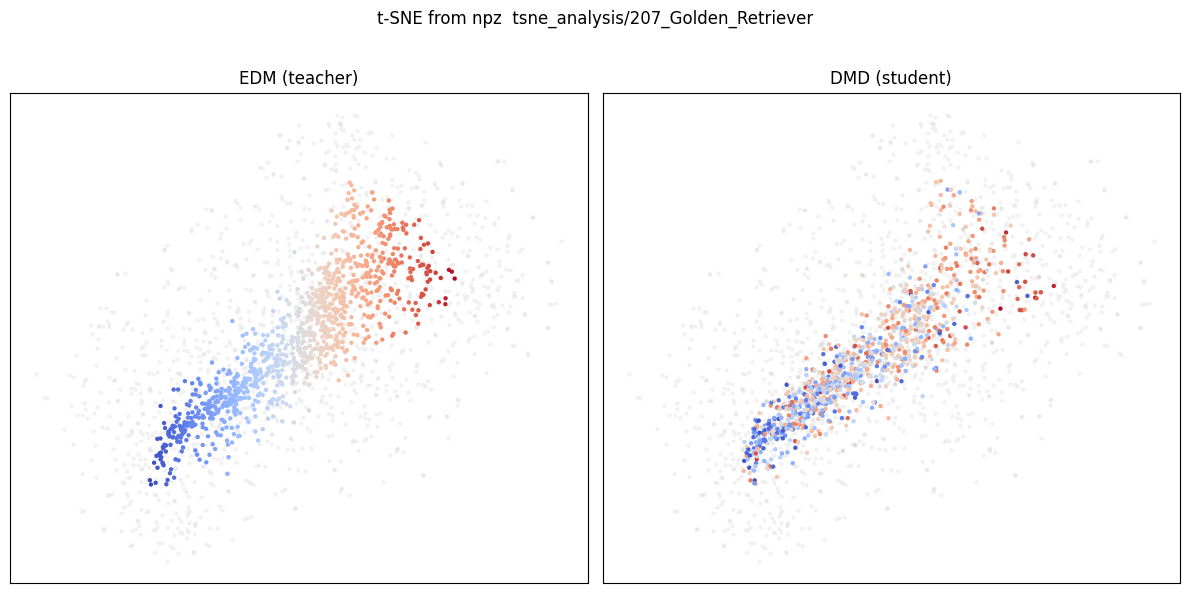

Saved tsne_analysis/207_Golden_Retriever/t_SNE_from_npz.png


In [24]:
# Fit t-SNE on training features only
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, init="pca", random_state=0, verbose=1)
bg_2d = tsne.fit_transform(bg_feats)

# Project EDM and DMD into same 2D space: k-NN in feature space → weighted avg of training t-SNE coords
from sklearn.neighbors import NearestNeighbors
k = min(50, n_bg)
nn = NearestNeighbors(n_neighbors=k, metric="euclidean").fit(bg_feats)
eps = 1e-8

def project_to_tsne(feats, nn, bg_2d, k, eps):
    dists, idx = nn.kneighbors(feats)
    weights = 1.0 / (dists.astype(np.float64) + eps)
    weights /= weights.sum(axis=1, keepdims=True)
    return (weights[:, :, None] * bg_2d[idx]).sum(axis=1)

edm_2d = project_to_tsne(edm_feats, nn, bg_2d, k, eps)
dmd_2d = project_to_tsne(dmd_feats, nn, bg_2d, k, eps)


min_pairs = min(n_edm, n_dmd)
edm_x = edm_2d[:min_pairs, 0].astype(np.float64)
x_min, x_max = edm_x.min(), edm_x.max()
x_norm = (edm_x - x_min) / (x_max - x_min + 1e-12)  # 0 = left, 1 = right

# EDM: left→right = blue→red; DMD: same color as corresponding EDM point (same noise seed)
cmap = plt.cm.get_cmap("coolwarm")  # blue (0) → red (1)
edm_colors = cmap(x_norm)  # (N, 4) RGBA
dmd_colors = edm_colors.copy()  # same color for matching index

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

for ax in axes:
    ax.scatter(bg_2d[:, 0], bg_2d[:, 1], s=5, c="lightgray", alpha=0.2, label="Train")
    ax.set_xticks([])
    ax.set_yticks([])

axes[0].scatter(edm_2d[:min_pairs, 0], edm_2d[:min_pairs, 1], s=10, color=edm_colors, edgecolors="none", label="EDM")
axes[0].set_title("EDM (teacher)")

axes[1].scatter(dmd_2d[:min_pairs, 0], dmd_2d[:min_pairs, 1], s=10, color=dmd_colors, edgecolors="none", label="DMD")
axes[1].set_title("DMD (student)")

fig.suptitle(f"t-SNE from npz  {CLASS_DIR}")
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f"{CLASS_DIR}/t_SNE_from_npz.png", dpi=200)
plt.show()
print(f"Saved {CLASS_DIR}/t_SNE_from_npz.png")